#Nama: Ridho Amanta Silaban
#NIM: 4222301091
#Kelas: Robotika C Pagi


##Tujuan: Membandingkan performa Multi-Layer Perceptron (MLP) menggunakan tiga fungsi aktivasi pada hidden layer:
1. **Sigmoid**
2. **Tanh**
3. **ReLU**

.


## 1. Import Library

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

sns.set_style('whitegrid')
RANDOM_STATE = 42
print("Library berhasil di-import.")


Library berhasil di-import.


## 2. Memuat Dataset Iris



In [17]:
import pandas as pd

df = pd.read_csv('Iris.csv')

print("Ukuran dataset:", df.shape)
print(df.head())

Ukuran dataset: (150, 6)
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [18]:
df.describe()


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


## 3. Exploratory Data Analysis (EDA)

Distribusi kelas:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


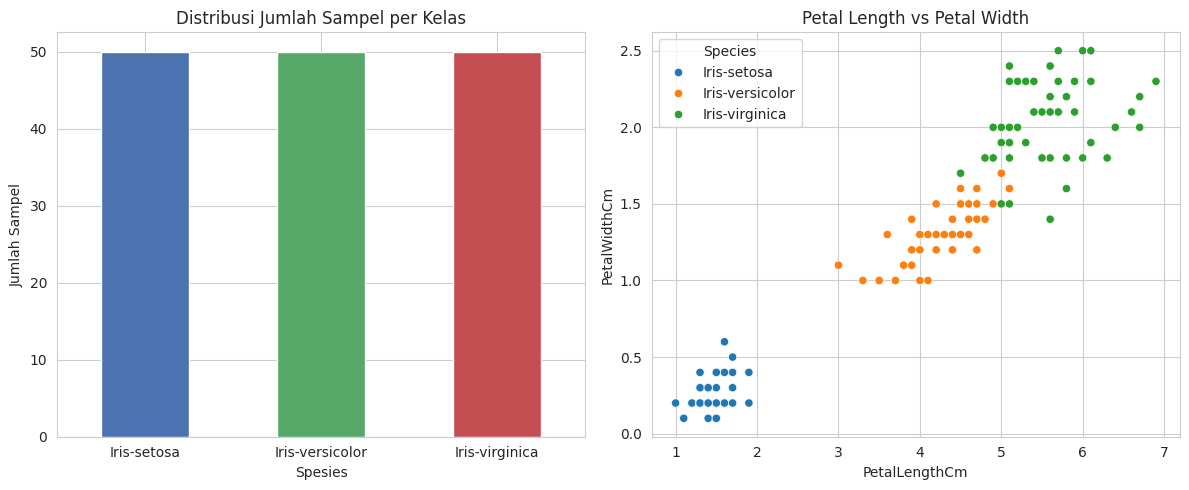

In [20]:
print("Distribusi kelas:")
print(df['Species'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['Species'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0', '#55A868', '#C44E52'])
axes[0].set_title('Distribusi Jumlah Sampel per Kelas')
axes[0].set_xlabel('Spesies')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].tick_params(axis='x', rotation=0)

sns.scatterplot(data=df, x='PetalLengthCm', y='PetalWidthCm', hue='Species', ax=axes[1])
axes[1].set_title('Petal Length vs Petal Width')

plt.tight_layout()
plt.show()

## 4. Preprocessing Data



In [22]:
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Data Training:", X_train_s.shape)
print("Data Testing :", X_test_s.shape)


Data Training: (120, 4)
Data Testing : (30, 4)


## 5. Membangun dan Melatih Model MLP dengan 3 Fungsi Aktivasi

Setiap model menggunakan arsitektur yang sama:
- Hidden layers: **2 layer, masing-masing 10 neuron** `(10, 10)`
- Solver: **Adam**
- Max iterations: **2000**
- Hanya **activation function** pada hidden layer yang dibedakan:
  - `logistic` -> Sigmoid
  - `tanh` -> Tanh
  - `relu` -> ReLU

In [23]:
activations = {'Sigmoid': 'logistic', 'Tanh': 'tanh', 'ReLU': 'relu'}
models = {}
single_results = []

for name, act in activations.items():
    start = time.time()
    model = MLPClassifier(
        hidden_layer_sizes=(10, 10),
        activation=act,
        solver='adam',
        max_iter=2000,
        random_state=RANDOM_STATE
    )
    model.fit(X_train_s, y_train)
    elapsed = time.time() - start

    models[name] = model
    y_pred = model.predict(X_test_s)

    single_results.append({
        'Fungsi Aktivasi': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision (macro)': round(precision_score(y_test, y_pred, average='macro'), 4),
        'Recall (macro)': round(recall_score(y_test, y_pred, average='macro'), 4),
        'F1-Score (macro)': round(f1_score(y_test, y_pred, average='macro'), 4),
        'Final Loss': round(model.loss_, 5),
        'Jumlah Iterasi': model.n_iter_,
        'Waktu Training (s)': round(elapsed, 4)
    })
    print(f"Model dengan aktivasi {name} selesai dilatih "
          f"(konvergen setelah {model.n_iter_} iterasi).")


Model dengan aktivasi Sigmoid selesai dilatih (konvergen setelah 1404 iterasi).
Model dengan aktivasi Tanh selesai dilatih (konvergen setelah 751 iterasi).
Model dengan aktivasi ReLU selesai dilatih (konvergen setelah 603 iterasi).


## 6. Visualisasi Loss Curve Selama Training

Grafik berikut menunjukkan bagaimana nilai loss menurun selama proses training untuk masing-masing fungsi aktivasi.

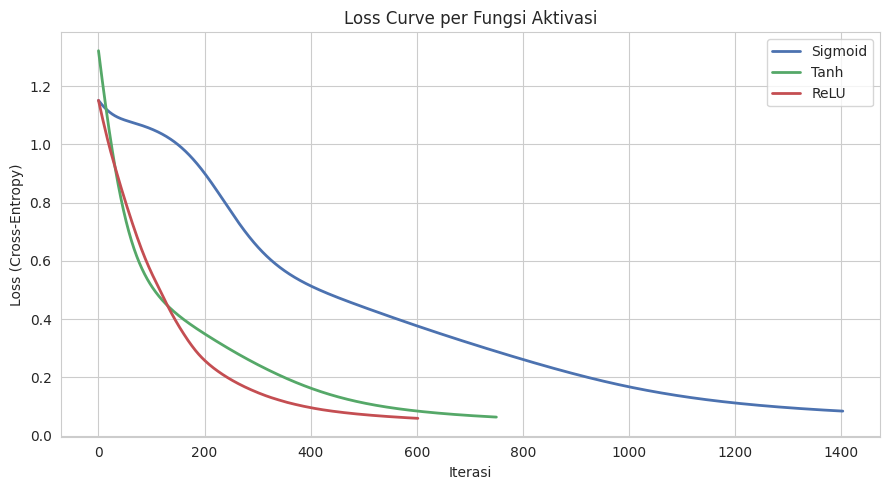

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = {'Sigmoid': '#4C72B0', 'Tanh': '#55A868', 'ReLU': '#C44E52'}

for name, model in models.items():
    ax.plot(model.loss_curve_, label=name, color=colors[name], linewidth=2)

ax.set_xlabel('Iterasi')
ax.set_ylabel('Loss (Cross-Entropy)')
ax.set_title('Loss Curve per Fungsi Aktivasi')
ax.legend()
plt.tight_layout()
plt.show()


## 7. Tabel Perbandingan Performa (Single Train/Test Split)

Tabel berikut membandingkan metrik performa setiap model pada data uji (20% data, `random_state=42`).

In [25]:
single_df = pd.DataFrame(single_results)
single_df


,Fungsi Aktivasi,Accuracy,Precision (macro),Recall (macro),F1-Score (macro),Final Loss,Jumlah Iterasi,Waktu Training (s)
0,Sigmoid,0.9667,0.9697,0.9667,0.9666,0.08383,1404,0.9520
1,Tanh,0.9667,0.9697,0.9667,0.9666,0.06333,751,0.5076
2,ReLU,0.9667,0.9697,0.9667,0.9666,0.05901,603,0.3115


## 8. Evaluasi yang Lebih Robust (Rata-rata 10 Percobaan)

Dataset Iris berukuran kecil (150 sampel) sehingga hasil dari **satu** split data bisa kebetulan sama/mirip untuk semua model.
Untuk perbandingan yang lebih adil dan stabil, kita ulangi proses train/test split + training sebanyak **10 kali** dengan `random_state` yang berbeda-beda, lalu hitung rata-rata dan standar deviasi setiap metrik.

In [27]:
n_runs = 10
all_results = {name: [] for name in activations}

for seed in range(n_runs):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)

    for name, act in activations.items():
        start = time.time()
        m = MLPClassifier(hidden_layer_sizes=(10, 10), activation=act,
                           solver='adam', max_iter=2000, random_state=seed)
        m.fit(X_tr_s, y_tr)
        elapsed = time.time() - start

        y_pred = m.predict(X_te_s)
        all_results[name].append({
            'accuracy': accuracy_score(y_te, y_pred),
            'f1': f1_score(y_te, y_pred, average='macro'),
            'loss': m.loss_,
            'iters': m.n_iter_,
            'time': elapsed
        })

print(f"Selesai menjalankan {n_runs} percobaan untuk setiap fungsi aktivasi.")


Selesai menjalankan 10 percobaan untuk setiap fungsi aktivasi.


In [28]:
summary = []
for name, results in all_results.items():
    rdf = pd.DataFrame(results)
    summary.append({
        'Fungsi Aktivasi': name,
        'Rata-rata Accuracy': round(rdf['accuracy'].mean(), 4),
        'Std Accuracy': round(rdf['accuracy'].std(), 4),
        'Rata-rata F1-Score': round(rdf['f1'].mean(), 4),
        'Rata-rata Final Loss': round(rdf['loss'].mean(), 5),
        'Rata-rata Jumlah Iterasi': round(rdf['iters'].mean(), 1),
        'Rata-rata Waktu Training (s)': round(rdf['time'].mean(), 4),
    })

summary_df = pd.DataFrame(summary)
summary_df


,Fungsi Aktivasi,Rata-rata Accuracy,Std Accuracy,Rata-rata F1-Score,Rata-rata Final Loss,Rata-rata Jumlah Iterasi,Rata-rata Waktu Training (s)
0,Sigmoid,0.9600,0.0263,0.9598,0.08382,1375.1,1.1618
1,Tanh,0.9600,0.0344,0.9598,0.06721,736.1,0.7673
2,ReLU,0.9567,0.0446,0.9566,0.05690,685.5,0.6671


## 9. Visualisasi Perbandingan Performa

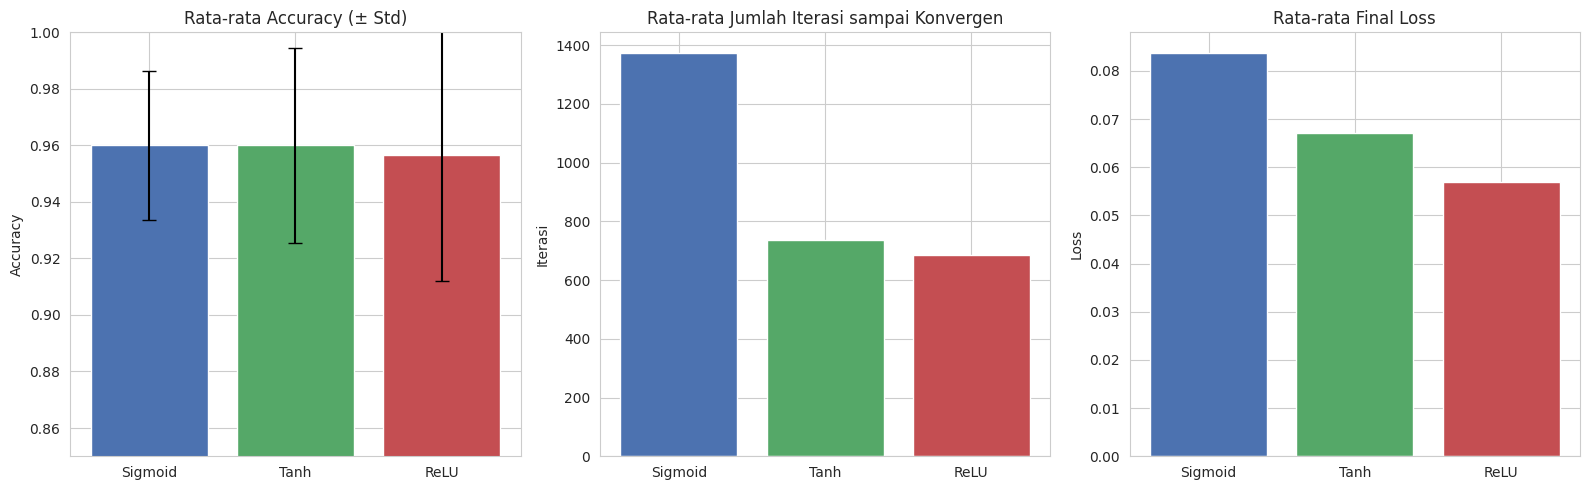

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
bar_colors = ['#4C72B0', '#55A868', '#C44E52']

axes[0].bar(summary_df['Fungsi Aktivasi'], summary_df['Rata-rata Accuracy'],
            yerr=summary_df['Std Accuracy'], capsize=5, color=bar_colors)
axes[0].set_title('Rata-rata Accuracy (± Std)')
axes[0].set_ylim(0.85, 1.0)
axes[0].set_ylabel('Accuracy')

axes[1].bar(summary_df['Fungsi Aktivasi'], summary_df['Rata-rata Jumlah Iterasi'], color=bar_colors)
axes[1].set_title('Rata-rata Jumlah Iterasi sampai Konvergen')
axes[1].set_ylabel('Iterasi')

axes[2].bar(summary_df['Fungsi Aktivasi'], summary_df['Rata-rata Final Loss'], color=bar_colors)
axes[2].set_title('Rata-rata Final Loss')
axes[2].set_ylabel('Loss')

plt.tight_layout()
plt.show()




###  Kesimpulan: Fungsi Aktivasi Terbaik untuk Dataset Iris

> **ReLU adalah pilihan terbaik secara keseluruhan untuk dataset Iris**, dengan **Tanh sebagai alternatif yang sangat kompetitif**.

Alasannya:
- **ReLU** memberikan **efisiensi komputasi terbaik** — konvergen jauh lebih cepat (jumlah iterasi & waktu training paling rendah) dengan akurasi yang tetap kompetitif (>95%). Untuk dataset yang lebih besar atau model yang lebih dalam, keunggulan efisiensi ReLU ini akan semakin terasa.
- **Tanh** menjadi pilihan baik jika prioritas utama adalah **stabilitas akurasi** — akurasinya setara/lebih tinggi dari ReLU dengan standar deviasi yang lebih kecil, namun waktu training sedikit lebih lama dari ReLU.
- **Sigmoid** adalah pilihan **paling tidak efisien** di antara ketiganya untuk dataset ini — meskipun akurasinya tetap baik, ia membutuhkan jumlah iterasi yang jauh lebih banyak untuk mencapai performa setara, akibat masalah vanishing gradient. Sigmoid umumnya hanya direkomendasikan untuk output layer pada masalah klasifikasi biner, bukan untuk hidden layer pada arsitektur modern.

